<table width="100%" style="border:none; border-collapse:collapse;">
<tr style="border:none;">
<td width="150" style="border:none;"></td>
<td align="center" style="border:none;">
    <h1>Tarea Semanal 7</h1>
    <h2>Teoria de los Circuitos II - R4052</h2>
    <h3>Fabian Alexander Iturrizaga Meza</h3>
    <br>
    <b>Docentes</b><br>
    Profesor: Mariano Llamedo Soria<br>
    Jefe de TPs: Cesar Fuoco<br>
    Ayudante de TPs: David Moharos
</td>
<td width="150" align="right" style="border:none; vertical-align:top;"><img src="./img/logo_UTN.svg" width="150" /></td>
</tr>
</table>

***

## Informe de la tarea semanal

Este notebook documenta la sintesis, simulacion y verificacion de redes pasivas correspondientes a la Tarea Semanal 7.

## Consigna

### Punto 1: Sintesis de una funcion de impedancia

Sea la funcion de impedancia:

$$Z(s)=\frac{s^4+4s^2+3}{s(s^2+2)}$$

Se pide hallar la topologia circuital y los valores de los componentes para:

- Sintesis de $Z(s)$ mediante Foster serie.
- Sintesis de $Y(s)=F(s)$ mediante Foster derivacion, usando la misma expresion de inmitancia dada arriba, no su inversa.
- Sintesis de $Z(s)$ mediante Cauer con remocion en infinito.
- Sintesis de $Z(s)$ mediante Cauer con remocion en continua.

Simular $Z(s)$ en LTspice, observando fase, pendientes y singularidades.

<div align="center"><img src="./img/consigna_ts7_1.png" alt="Consigna TS7 punto 1" width="700"/></div>

### Punto 2: Sintesis mediante mapa de remociones

Esquematizar el mapa de remociones mediante el metodo grafico y hallar los componentes para:

$$Y(s)=\frac{s^5+18s^3+48s}{6s^4+42s^2+48}$$

<div align="center"><img src="./img/consigna_ts7_2.png" alt="Consigna TS7 punto 2" width="700"/></div>

En todos los casos verificar los resultados mediante Python con `pytc2` y mediante LTspice.

## Indice

- [Punto 1: sintesis de $Z(s)$ mediante Foster](#p1)
- [Punto 1: sintesis de $Z(s)$ mediante Cauer](#p2)
- [Punto 2: mapa de remociones para $Y(s)$](#p3)
- [Verificacion simbolica y circuital](#p4)

In [11]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Math, Image
from io import BytesIO
from schemdraw import Drawing
import schemdraw
import pytc2
import pytc2.dibujar as dibujos_pytc2
from pytc2.general import s, print_latex, print_subtitle, a_equal_b_latex_s
from pytc2.sintesis_dipolo import foster, cauer_LC
from pytc2.remociones import isFRP, remover_polo_dc, remover_polo_jw
from pytc2.dibujar import (
    dibujar_foster_serie,
    dibujar_cauer_LC,
    dibujar_puerto_entrada,
    dibujar_funcion_exc_abajo,
    dibujar_elemento_derivacion,
    dibujar_espacio_derivacion,
    dibujar_tanque_derivacion,
)

print(f'PyTC2: {pytc2.__version__}')

schemdraw.use('matplotlib')
schemdraw.config(color='black', bgcolor='white', fontsize=14)


def mostrar_circuito(dibujo):
    figura = dibujo.draw(show=False, canvas='matplotlib').getfig()
    imagen = BytesIO()
    figura.savefig(
        imagen,
        format='png',
        dpi=160,
        bbox_inches='tight',
        pad_inches=0.15,
        facecolor='white',
        transparent=False,
    )
    ancho = min(900, round(figura.get_figwidth() * 85))
    plt.close(figura)
    display(Image(data=imagen.getvalue(), format='png', width=ancho))


dibujos_pytc2.display = mostrar_circuito


def dibujar_foster_derivacion_lc(k0, koo, ki, y_exc):
    dibujo = Drawing(unit=4, canvas='matplotlib')
    dibujo = dibujar_puerto_entrada(
        dibujo,
        voltage_lbl=('+', '$V$', '-'),
        current_lbl='$I$',
    )
    dibujo = dibujar_funcion_exc_abajo(
        dibujo,
        'Y',
        y_exc,
        hacia_salida=True,
        k_gap_width=0.5,
    )
    hay_rama = False

    if not k0.is_zero:
        dibujo = dibujar_elemento_derivacion(dibujo, 'L', 1 / k0)
        hay_rama = True
    if not koo.is_zero:
        if hay_rama:
            dibujar_espacio_derivacion(dibujo)
        dibujo = dibujar_elemento_derivacion(dibujo, 'C', koo)
        hay_rama = True
    for termino in ki:
        if hay_rama:
            dibujar_espacio_derivacion(dibujo)
        dibujo = dibujar_tanque_derivacion(
            dibujo,
            inductor_label=termino[1],
            capacitor_label=1 / termino[0],
        )
        hay_rama = True

    mostrar_circuito(dibujo)


F = (s**4 + 4 * s**2 + 3) / (s * (s**2 + 2))
Z = F
Y_punto1 = F
Y_punto2 = (s**5 + 18 * s**3 + 48 * s) / (6 * s**4 + 42 * s**2 + 48)

print_latex(a_equal_b_latex_s('F(s)', F))
print_latex(a_equal_b_latex_s('Z(s)=F(s)', Z))
print_latex(a_equal_b_latex_s('Y_1(s)=F(s)', Y_punto1))
print_latex(a_equal_b_latex_s('Y_2(s)', Y_punto2))
print('Z=F y Y_1=F son FRP:', isFRP(Z), isFRP(Y_punto1))
print('Y_2 es FRP:', isFRP(Y_punto2))

PyTC2: 0.2.1


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Z=F y Y_1=F son FRP: True True
Y_2 es FRP: True


<a id="p1"></a>

***

# Punto 1

## Sintesis de $Z(s)$ mediante Foster

### 1.a Foster serie

Descomponer $Z(s)$ en fracciones simples y asociar cada termino con una rama serie $R$, $L$ o $C$.

### Resolucion manuscrita

<div align="center"><img src="./img/punto1a-1.png" alt="Desarrollo manuscrito de la sintesis Foster serie, parte 1" width="700"/></div>
<div align="center"><img src="./img/punto1a-2.png" alt="Desarrollo manuscrito de la sintesis Foster serie, parte 2" width="700"/></div>

### Simulacion en LTspice

<div align="center"><img src="./img/punto1a-circuito.png" alt="Circuito de la realizacion Foster serie del punto 1a" width="700"/></div>

**Nota:** El esquema corresponde a la realizacion Foster serie de $Z(s)$.

<div align="center"><img src="./img/punto1a-fase.png" alt="Fase simulada para el punto 1a" width="100%"/></div>

**Nota importante sobre la fase:** Se omitio el signo $-1$ de la corriente. Por eso el grafico de fase aparece invertido respecto del modelo de cuadripolos: LTspice toma la corriente con una referencia de sentido opuesta a la que definimos en el modelo. Se conserva la captura por practicidad, sin volver a generar las imagenes.

<div align="center"><img src="./img/punto1a-cero1.png" alt="Verificacion del Cero 1 del punto 1a" width="100%"/></div>

**Nota:** El Cero 1 debe ubicarse en $1\,\mathrm{rad/s}$, equivalente a aproximadamente $159\,\mathrm{mHz}$. El cursor de la imagen verifica correctamente esta ubicacion.

<div align="center"><img src="./img/punto1a-polo1.png" alt="Verificacion del Polo 1 del punto 1a" width="100%"/></div>

**Nota:** El Polo 1 debe ubicarse en $\sqrt{2}\,\mathrm{rad/s}$, equivalente a aproximadamente $225\,\mathrm{mHz}$. El cursor de la imagen verifica correctamente esta ubicacion.

<div align="center"><img src="./img/punto1a-cero2.png" alt="Verificacion del Cero 2 del punto 1a" width="100%"/></div>

**Nota:** El Cero 2 debe ubicarse en $\sqrt{3}\,\mathrm{rad/s}$, equivalente a aproximadamente $275\,\mathrm{mHz}$. El cursor de la imagen verifica correctamente esta ubicacion.

#### Punto 1a: sintesis Foster serie de Z(s)

<IPython.core.display.Math object>

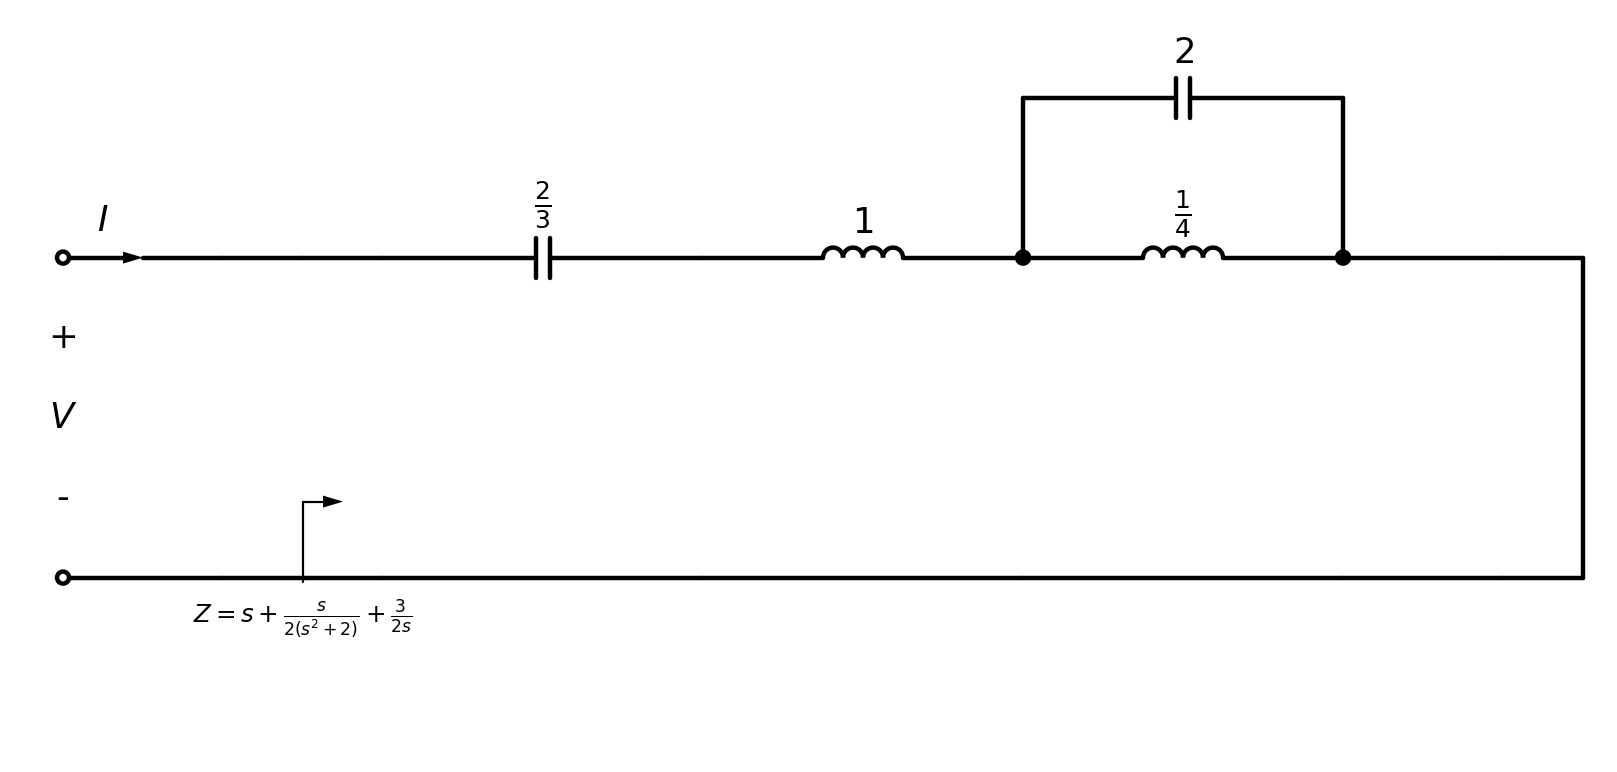

In [12]:
print_subtitle('Punto 1a: sintesis Foster serie de Z(s)')
k0_z, koo_z, ki_z, kk_z, Z_foster = foster(Z)
print_latex(a_equal_b_latex_s('Z_Foster(s)', Z_foster))
assert sp.cancel(Z_foster - Z) == 0
dibujar_foster_serie(k0_z, koo_z, ki_z, z_exc=Z_foster)

### 1.b Foster derivacion para $Y(s)$

Para este inciso se toma como admitancia objetivo la misma expresion de inmitancia dada en la consigna: $Y(s)=F(s)=Z(s)$. No se calcula el inverso $1/Z(s)$; se realiza la red dual en derivacion.

### Resolucion manuscrita

<div align="center"><img src="./img/punto1b-1.png" alt="Desarrollo manuscrito de la sintesis Foster en derivacion del punto 1b" width="700"/></div>

### Simulacion en LTspice

<div align="center"><img src="./img/punto1b-circuito.png" alt="Circuito de la realizacion Foster en derivacion del punto 1b" width="700"/></div>

**Nota:** El circuito corresponde a Foster en derivacion para $Y(s)=F(s)$. Sus valores coinciden con la realizacion mostrada: $L_1=2/3$, $C_1=1$, rama serie $C_2=1/4$ y $L_2=2$.

<div align="center"><img src="./img/punto1b-fase.png" alt="Fase simulada para el punto 1b" width="100%"/></div>

**Nota importante sobre la fase:** Se omitio el signo $-1$ de la corriente. Por eso el grafico de fase aparece invertido respecto del modelo de cuadripolos: LTspice toma la corriente con una referencia de sentido opuesta a la que definimos en el modelo. Se conserva la captura por practicidad, sin volver a generar las imagenes.

<div align="center"><img src="./img/punto1b-cero1.png" alt="Verificacion del Cero 1 del punto 1b" width="100%"/></div>

**Nota:** El Cero 1 de $Y(s)=F(s)$ debe ubicarse en $1\,\mathrm{rad/s}$, aproximadamente $159\,\mathrm{mHz}$. La captura lo verifica correctamente.

<div align="center"><img src="./img/punto1b-polo1.png" alt="Verificacion del Polo 1 del punto 1b" width="100%"/></div>

**Nota:** El Polo 1 de $Y(s)=F(s)$ debe ubicarse en $\sqrt{2}\,\mathrm{rad/s}$, aproximadamente $225\,\mathrm{mHz}$. La captura lo verifica correctamente.

<div align="center"><img src="./img/punto1b-cero2.png" alt="Verificacion del Cero 2 del punto 1b" width="100%"/></div>

**Nota:** El Cero 2 de $Y(s)=F(s)$ debe ubicarse en $\sqrt{3}\,\mathrm{rad/s}$, aproximadamente $275\,\mathrm{mHz}$. La captura lo verifica correctamente.

#### Punto 1b: sintesis Foster en derivacion de Y(s)=F(s)

<IPython.core.display.Math object>

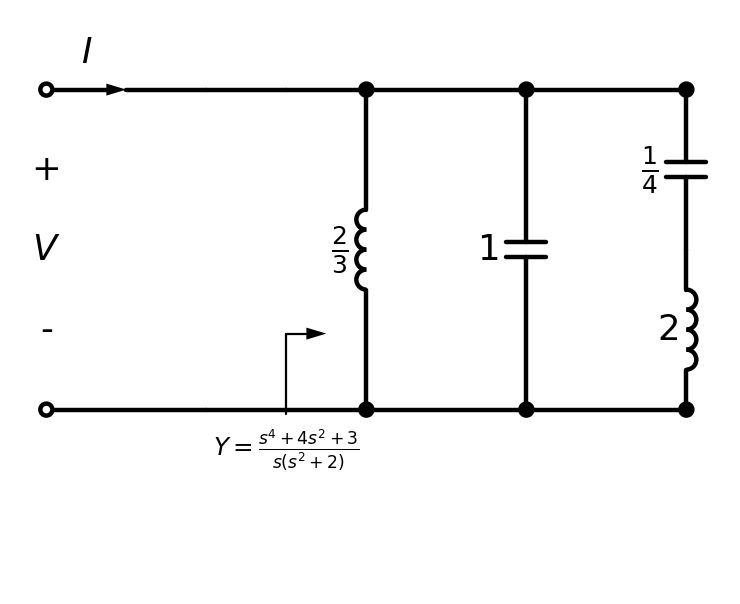

In [13]:
print_subtitle('Punto 1b: sintesis Foster en derivacion de Y(s)=F(s)')
k0_y1, koo_y1, ki_y1, kk_y1, Y1_foster = foster(F)
print_latex(a_equal_b_latex_s('Y_{Foster}(s)=F(s)', Y1_foster))
assert sp.cancel(Y1_foster - F) == 0
dibujar_foster_derivacion_lc(k0_y1, koo_y1, ki_y1, y_exc=F)

<a id="p2"></a>

***

## Sintesis de $Z(s)$ mediante Cauer

### 1.c Remocion en infinito

Desarrollar la fraccion continua de $Z(s)$ alrededor de $s\to\infty$.

### Resolucion manuscrita

<div align="center"><img src="./img/punto1c-1.png" alt="Desarrollo manuscrito de la sintesis Cauer por remocion en infinito" width="700"/></div>

### Simulacion en LTspice

<div align="center"><img src="./img/punto1c-circuito.png" alt="Circuito de la realizacion Cauer del punto 1c" width="700"/></div>

**Nota:** El esquema corresponde a la realizacion Cauer de $Z(s)$ mediante remocion en infinito.

<div align="center"><img src="./img/punto1c-fase.png" alt="Fase simulada para el punto 1c" width="100%"/></div>

**Nota importante sobre la fase:** Se omitio el signo $-1$ de la corriente. Por eso el grafico de fase aparece invertido respecto del modelo de cuadripolos: LTspice toma la corriente con una referencia de sentido opuesta a la que definimos en el modelo. Se conserva la captura por practicidad, sin volver a generar las imagenes.

<div align="center"><img src="./img/punto1c-cero1.png" alt="Verificacion del Cero 1 del punto 1c" width="100%"/></div>

**Nota:** El Cero 1 debe ubicarse en $1\,\mathrm{rad/s}$, equivalente a aproximadamente $159\,\mathrm{mHz}$. El cursor de la imagen verifica correctamente esta ubicacion.

<div align="center"><img src="./img/punto1c-polo1.png" alt="Verificacion del Polo 1 del punto 1c" width="100%"/></div>

**Nota:** El Polo 1 debe ubicarse en $\sqrt{2}\,\mathrm{rad/s}$, equivalente a aproximadamente $225\,\mathrm{mHz}$. El cursor de la imagen verifica correctamente esta ubicacion.

<div align="center"><img src="./img/punto1c-cero2.png" alt="Verificacion del Cero 2 del punto 1c" width="100%"/></div>

**Nota:** El Cero 2 debe ubicarse en $\sqrt{3}\,\mathrm{rad/s}$, equivalente a aproximadamente $275\,\mathrm{mHz}$. El cursor de la imagen verifica correctamente esta ubicacion.

#### Punto 1c: sintesis Cauer I, remociones en infinito

<IPython.core.display.Math object>

<IPython.core.display.Math object>

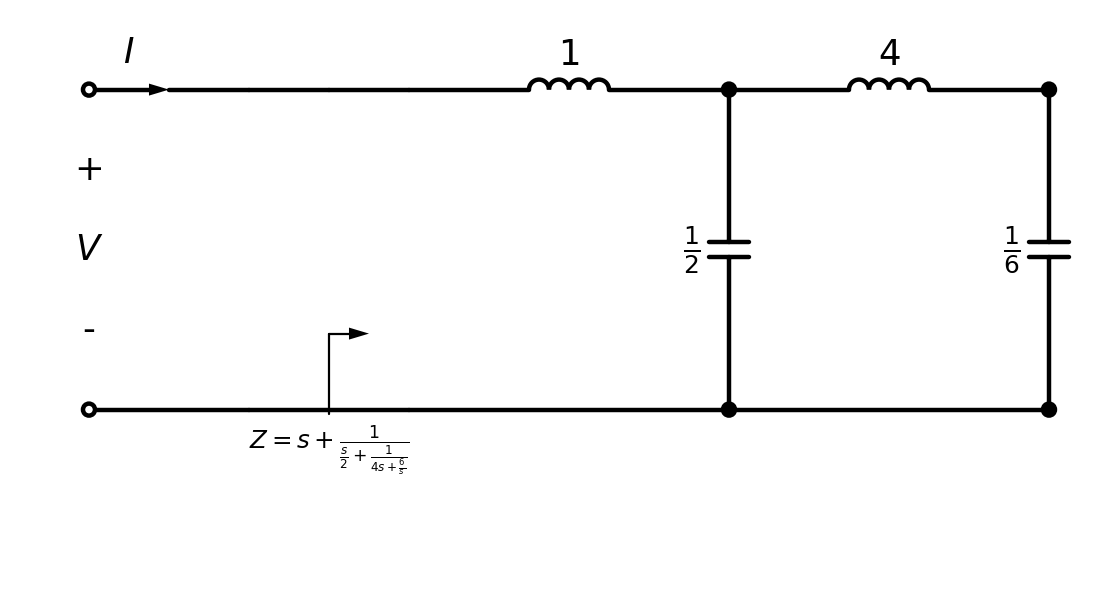

In [14]:
print_subtitle('Punto 1c: sintesis Cauer I, remociones en infinito')
terminos_cauer_inf, Z_cauer_inf, remanente_inf = cauer_LC(
    Z,
    remover_en_inf=True,
)
print_latex(a_equal_b_latex_s('Z_{Cauer I}(s)', Z_cauer_inf))
print_latex(a_equal_b_latex_s('Remanente_{Cauer I}', remanente_inf))
assert sp.cancel(Z_cauer_inf - Z) == 0
assert sp.cancel(remanente_inf) == 0
dibujar_cauer_LC(terminos_cauer_inf, z_exc=Z_cauer_inf)

### 1.d Remocion en continua

Desarrollar la fraccion continua alrededor de $s\to0$.

### Resolucion manuscrita

<div align="center"><img src="./img/punto1d-1.png" alt="Desarrollo manuscrito de la sintesis Cauer por remocion en continua, parte 1" width="700"/></div>
<div align="center"><img src="./img/punto1d-2.png" alt="Desarrollo manuscrito de la sintesis Cauer por remocion en continua, parte 2" width="700"/></div>

### Simulacion en LTspice

<div align="center"><img src="./img/punto1d-circuito.png" alt="Circuito de la realizacion Cauer del punto 1d" width="700"/></div>

**Nota:** El esquema corresponde a la realizacion Cauer de $Z(s)$ mediante remocion en continua.

<div align="center"><img src="./img/punto1d-fase.png" alt="Fase simulada para el punto 1d" width="100%"/></div>

**Nota importante sobre la fase:** Se omitio el signo $-1$ de la corriente. Por eso el grafico de fase aparece invertido respecto del modelo de cuadripolos: LTspice toma la corriente con una referencia de sentido opuesta a la que definimos en el modelo. Se conserva la captura por practicidad, sin volver a generar las imagenes.

<div align="center"><img src="./img/punto1d-fase-cero1.png" alt="Fase y cursor de verificacion del Cero 1 del punto 1d" width="100%"/></div>

**Nota importante sobre la fase y el Cero 1:** La captura de fase esta invertida por el signo $-1$ omitido en la corriente, como se explico arriba. El cursor ubica correctamente el Cero 1 en $1\,\mathrm{rad/s}$, aproximadamente $159\,\mathrm{mHz}$.

<div align="center"><img src="./img/punto1d-fase-polo1.png" alt="Fase y cursor de verificacion del Polo 1 del punto 1d" width="100%"/></div>

**Nota importante sobre la fase y el Polo 1:** La captura de fase esta invertida por el signo $-1$ omitido en la corriente, como se explico arriba. El cursor ubica correctamente el Polo 1 en $\sqrt{2}\,\mathrm{rad/s}$, aproximadamente $225\,\mathrm{mHz}$.

<div align="center"><img src="./img/punto1d-polo1.png" alt="Verificacion del Polo 1 del punto 1d" width="100%"/></div>

**Nota:** El Polo 1 debe ubicarse en $\sqrt{2}\,\mathrm{rad/s}$, equivalente a aproximadamente $225\,\mathrm{mHz}$. El cursor de la imagen verifica correctamente esta ubicacion.

<div align="center"><img src="./img/punto1d-fase-cero2.png" alt="Fase y cursor de verificacion del Cero 2 del punto 1d" width="100%"/></div>

**Nota importante sobre la fase y el Cero 2:** La captura de fase esta invertida por el signo $-1$ omitido en la corriente, como se explico arriba. El cursor ubica correctamente el Cero 2 en $\sqrt{3}\,\mathrm{rad/s}$, aproximadamente $275\,\mathrm{mHz}$.

<div align="center"><img src="./img/punto1d-cero2.png" alt="Verificacion del Cero 2 del punto 1d" width="100%"/></div>

**Nota:** El Cero 2 debe ubicarse en $\sqrt{3}\,\mathrm{rad/s}$, equivalente a aproximadamente $275\,\mathrm{mHz}$. El cursor de la imagen verifica correctamente esta ubicacion.

#### Punto 1d: sintesis Cauer II, remociones en continua

<IPython.core.display.Math object>

<IPython.core.display.Math object>

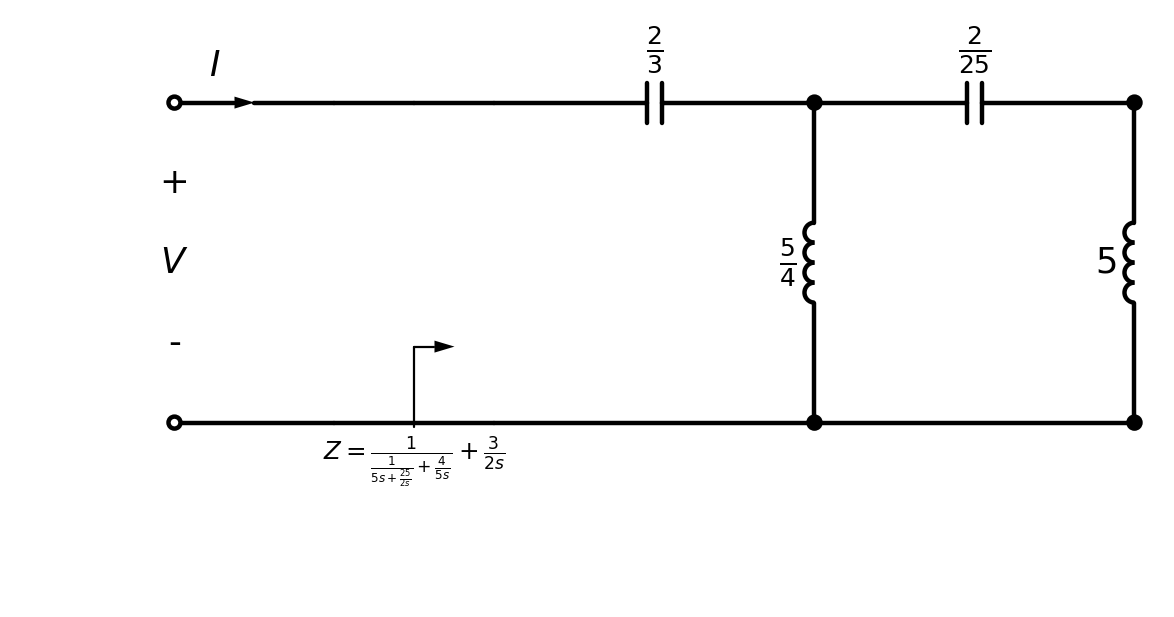

In [15]:
print_subtitle('Punto 1d: sintesis Cauer II, remociones en continua')
terminos_cauer_dc, Z_cauer_dc, remanente_dc = cauer_LC(
    Z,
    remover_en_inf=False,
)
print_latex(a_equal_b_latex_s('Z_{Cauer II}(s)', Z_cauer_dc))
print_latex(a_equal_b_latex_s('Remanente_{Cauer II}', remanente_dc))
assert sp.cancel(Z_cauer_dc - Z) == 0
assert sp.cancel(remanente_dc) == 0
dibujar_cauer_LC(terminos_cauer_dc, z_exc=Z_cauer_dc)

<a id="p3"></a>

***

## 2. Mapa de remociones para $Y(s)$

Graficar el mapa de remociones, indicar cada paso de extraccion y calcular los valores de los componentes.

<div align="center"><img src="./img/consigna_ts7_2.png" alt="Consigna del punto 2" width="650"/></div>

### Resolucion manuscrita

<div align="center"><img src="./img/punto2-1.png" alt="Resolucion manuscrita del punto 2, parte 1" width="700"/></div>
<div align="center"><img src="./img/punto2-2.png" alt="Resolucion manuscrita del punto 2, parte 2" width="700"/></div>
<div align="center"><img src="./img/punto2-3.png" alt="Resolucion manuscrita del punto 2, parte 3" width="700"/></div>
<div align="center"><img src="./img/punto2-4.png" alt="Resolucion manuscrita del punto 2, parte 4" width="700"/></div>

### Simulacion en LTspice

<div align="center"><img src="./img/punto2-circuito.png" alt="Circuito simulado del punto 2" width="700"/></div>

**Nota:** La realizacion corresponde a la red obtenida por el mapa de remociones. En estas simulaciones se tomo correctamente el sentido de la corriente: para la fase se grafico `-I(V1)/V(vin)`, consistente con la referencia de corriente adoptada para la funcion de entrada.

<div align="center"><img src="./img/punto2-fase.png" alt="Fase de la admitancia del punto 2, con sentido de corriente corregido" width="100%"/></div>

**Nota sobre la fase:** La traza incluye el signo negativo de la corriente, por lo que el sentido queda correctamente referido y no aparece la inversion observada en las capturas de los puntos 1a–1d. La secuencia de tramos de fase concuerda con los polos y ceros de $Y(s)$.

### Verificacion de polos y ceros

De la transferencia

$$Y(s)=\frac{s(s^4+18s^2+48)}{6(s^4+7s^2+8)}$$

se obtienen los polos finitos al resolver $\omega^4-7\omega^2+8=0$ y los ceros finitos al resolver $\omega^4-18\omega^2+48=0$. La conversion de frecuencia angular a frecuencia en hertz se realiza con $f=\omega/(2\pi)$.

| Singularidad | $\omega$ (rad/s) | $f$ teorica (mHz) | Cursor LTspice (mHz) |
|---|---:|---:|---:|
| Polo 1 | $\sqrt{(7-\sqrt{17})/2}\approx1{,}19935$ | 190,88 | 190,897 |
| Cero 1 | $\sqrt{9-\sqrt{33}}\approx1{,}80428$ | 287,16 | 287,144 |
| Polo 2 | $\sqrt{(7+\sqrt{17})/2}\approx2{,}35829$ | 375,33 | 375,319 |
| Cero 2 | $\sqrt{9+\sqrt{33}}\approx3{,}83986$ | 611,13 | 611,083 |

Las frecuencias de los cursores concuerdan con las singularidades calculadas a partir de la transferencia en rad/s.

#### Polo 1

<div align="center"><img src="./img/punto2-polo1.png" alt="Cursor de magnitud en el Polo 1, cerca de 190.897 mHz" width="100%"/></div>

El cursor mide aproximadamente **190,897 mHz**, en acuerdo con los $190,88\,\mathrm{mHz}$ calculados.

#### Cero 1

<div align="center"><img src="./img/punto2-cero1.png" alt="Cursor de magnitud en el Cero 1, cerca de 287.144 mHz" width="100%"/></div>

El cursor mide aproximadamente **287,144 mHz**, en acuerdo con los $287,16\,\mathrm{mHz}$ calculados.

#### Polo 2

<div align="center"><img src="./img/punto2-polo2.png" alt="Cursor de magnitud en el Polo 2, cerca de 375.319 mHz" width="100%"/></div>

El cursor mide aproximadamente **375,319 mHz**, en acuerdo con los $375,33\,\mathrm{mHz}$ calculados.

#### Cero 2

<div align="center"><img src="./img/punto2-cero2.png" alt="Cursor de magnitud en el Cero 2, cerca de 611.083 mHz" width="100%"/></div>

El cursor mide aproximadamente **611,083 mHz**, en acuerdo con los $611,13\,\mathrm{mHz}$ calculados.

### Cursores sobre la fase

Las capturas adicionales muestran la fase con la misma referencia de corriente corregida, en frecuencias cercanas a cada singularidad.

<div align="center"><img src="./img/punto2-fase-polo1.png" alt="Fase y cursor cerca del Polo 1, con corriente correctamente referida" width="100%"/></div>

**Polo 1:** el cursor marca aproximadamente 190,853 mHz y la fase mantiene el sentido esperado en el primer cambio.

<div align="center"><img src="./img/punto2-fase-cero1.png" alt="Fase y cursor cerca del Cero 1, con corriente correctamente referida" width="100%"/></div>

**Cero 1:** el cursor marca aproximadamente 287,144 mHz. La frecuencia corresponde al cero calculado de $Y(s)$; la lectura es cercana a 287 mHz, no 297 mHz.

<div align="center"><img src="./img/punto2-fase-polo2.png" alt="Fase y cursor cerca del Polo 2, con corriente correctamente referida" width="100%"/></div>

**Polo 2:** el cursor marca aproximadamente 375,405 mHz, próximo a los 375,33 mHz teóricos.

<div align="center"><img src="./img/punto2-fase-cero2.png" alt="Fase y cursor cerca del Cero 2, con corriente correctamente referida" width="100%"/></div>

**Cero 2:** el cursor marca aproximadamente 611,223 mHz, próximo a los 611,13 mHz teóricos.


#### Punto 2: mapa de remociones de Y(s)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Polos finitos de Y: [1.1993528201455856, 2.3582944711822633] rad/s
Ceros finitos no nulos de Y: [1.8042830580210998, 3.8398649255589743] rad/s
Cero de Z2 / polo de Y4: 2.1908902300206643 rad/s
Frecuencia del tanque: 2.8284271247461903 rad/s


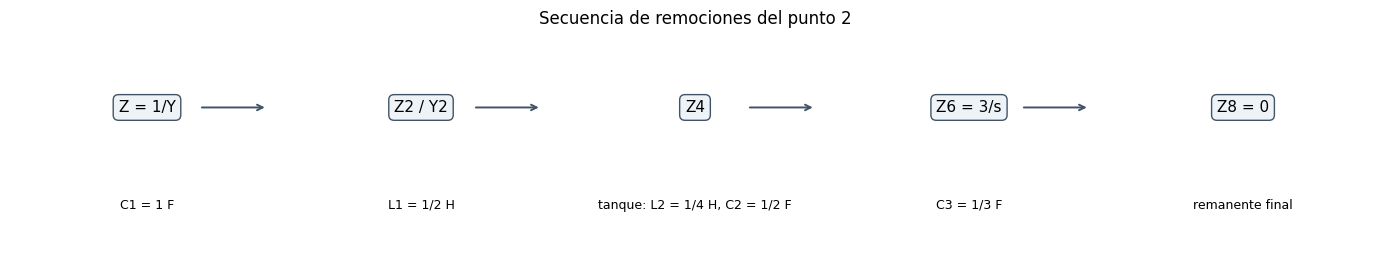

In [16]:
print_subtitle('Punto 2: mapa de remociones de Y(s)')

Z_ej2 = sp.cancel(1 / Y_punto2)
Z2, Z_C1 = remover_polo_dc(Z_ej2)
Y2 = sp.cancel(1 / Z2)
Y4, Y_L1 = remover_polo_dc(Y2)
Z4 = sp.cancel(1 / Y4)

C1_ej2 = sp.simplify(1 / (s * Z_C1))
L1_ej2 = sp.simplify(1 / (s * Y_L1))
for nombre, expresion in [
    ('Z(s)', Z_ej2),
    ('Z_{C_1}(s)', Z_C1),
    ('Z_2(s)', Z2),
    ('Y_2(s)', Y2),
    ('Y_{L_1}(s)', Y_L1),
    ('Y_4(s)', Y4),
    ('Z_4(s)', Z4),
]:
    print_latex(a_equal_b_latex_s(nombre, sp.cancel(expresion)))

escala = sp.sqrt(8)
Z4_normalizada = sp.cancel(Z4.subs(s, escala * s))
Z6_n, Z_tanque_n, L2_n, C2_n = remover_polo_jw(
    Z4_normalizada,
    omega=1,
    isImpedance=True,
)
Z6 = sp.cancel(Z6_n.subs(s, s / escala))
Z_tanque = sp.cancel(Z_tanque_n.subs(s, s / escala))
L2_ej2 = sp.simplify(L2_n / escala)
C2_ej2 = sp.simplify(C2_n / escala)

Z8, Z_C3 = remover_polo_dc(Z6)
C3_ej2 = sp.simplify(1 / (s * Z_C3))

for nombre, expresion in [
    ('Z_{tanque}(s)', Z_tanque),
    ('Z_6(s)', Z6),
    ('Z_8(s)', Z8),
]:
    print_latex(a_equal_b_latex_s(nombre, sp.cancel(expresion)))
for nombre, valor in [
    ('C_1', C1_ej2),
    ('L_1', L1_ej2),
    ('L_2', L2_ej2),
    ('C_2', C2_ej2),
    ('C_3', C3_ej2),
]:
    print_latex(a_equal_b_latex_s(nombre, valor))

assert sp.cancel(Z2 - s * (5 * s**2 + 24) / (s**4 + 18 * s**2 + 48)) == 0
assert sp.cancel(Y4 - s * (s**2 + 8) / (5 * s**2 + 24)) == 0
assert sp.cancel(Z_tanque - 2 * s / (s**2 + 8)) == 0
assert sp.cancel(Z6 - 3 / s) == 0
assert sp.cancel(Z8) == 0

Z_tanque_red = 1 / (s * C2_ej2 + 1 / (s * L2_ej2))
Z_rama_derecha = Z_tanque_red + 1 / (s * C3_ej2)
Z_derivacion = 1 / (1 / (s * L1_ej2) + 1 / Z_rama_derecha)
Z_red_ej2 = 1 / (s * C1_ej2) + Z_derivacion
Y_red_ej2 = sp.cancel(1 / Z_red_ej2)
print_latex(a_equal_b_latex_s('Y_{red}(s)', Y_red_ej2))
diferencia_ej2 = sp.cancel(Y_red_ej2 - Y_punto2)
print_latex(a_equal_b_latex_s('Y_{red}(s)-Y(s)', diferencia_ej2))
assert diferencia_ej2 == 0

polos_Y = [
    sp.sqrt((7 - sp.sqrt(17)) / 2),
    sp.sqrt((7 + sp.sqrt(17)) / 2),
]
ceros_Y = [sp.sqrt(9 - sp.sqrt(33)), sp.sqrt(9 + sp.sqrt(33))]
print('Polos finitos de Y:', [float(omega) for omega in polos_Y], 'rad/s')
print('Ceros finitos no nulos de Y:', [float(omega) for omega in ceros_Y], 'rad/s')
print('Cero de Z2 / polo de Y4:', float(sp.sqrt(sp.Rational(24, 5))), 'rad/s')
print('Frecuencia del tanque:', float(sp.sqrt(8)), 'rad/s')

figura, ax = plt.subplots(figsize=(14, 2.8))
etapas = [
    ('Z = 1/Y', 'C1 = 1 F'),
    ('Z2 / Y2', 'L1 = 1/2 H'),
    ('Z4', 'tanque: L2 = 1/4 H, C2 = 1/2 F'),
    ('Z6 = 3/s', 'C3 = 1/3 F'),
    ('Z8 = 0', 'remanente final'),
]
ax.set_xlim(0, len(etapas))
ax.set_ylim(0, 1)
ax.axis('off')
for indice, (estado, extraccion) in enumerate(etapas):
    ax.text(
        indice + 0.5,
        0.67,
        estado,
        ha='center',
        va='center',
        fontsize=11,
        bbox={'boxstyle': 'round,pad=0.35', 'facecolor': '#eef3f7', 'edgecolor': '#425466'},
    )
    ax.text(indice + 0.5, 0.24, extraccion, ha='center', va='center', fontsize=9)
    if indice < len(etapas) - 1:
        ax.annotate(
            '',
            xy=(indice + 0.94, 0.67),
            xytext=(indice + 0.69, 0.67),
            arrowprops={'arrowstyle': '->', 'color': '#425466', 'lw': 1.4},
        )
ax.set_title('Secuencia de remociones del punto 2', fontsize=12)
plt.tight_layout()
plt.show()